<a href="https://colab.research.google.com/github/ancestor9/2026_Fall_Generative-Deep-Learning/blob/main/scripts/Hello_Wrodl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

전체 데이터 크기: (1000, 1025)


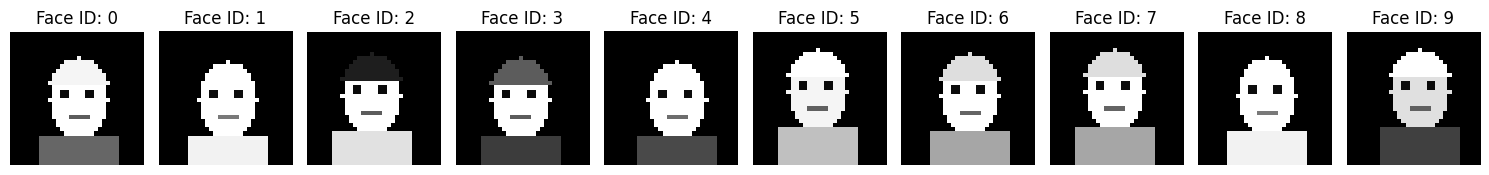

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CSV 데이터 불러오기
df = pd.read_csv('/content/planet_pixel_faces.csv')

# 데이터 기본 정보 확인 및 5개 샘플 추출
print(f"전체 데이터 크기: {df.shape}")
samples = df.head(10)

# 2. 이미지 5개 시각화
fig, axes = plt.subplots(1, 10, figsize=(15, 3.5))

# 'px_'로 시작하는 픽셀 열만 선택
pixel_cols = [col for col in df.columns if col.startswith('px_')]

for i, (_, row) in enumerate(samples.iterrows()):
    # 픽셀 값 추출
    pixel_data = row[pixel_cols].values.astype(float)

    # 1024개 픽셀이므로 32x32 크기로 복원
    img = pixel_data.reshape(32, 32)

    # 시각화 출력
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Face ID: {int(row['face_id'])}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

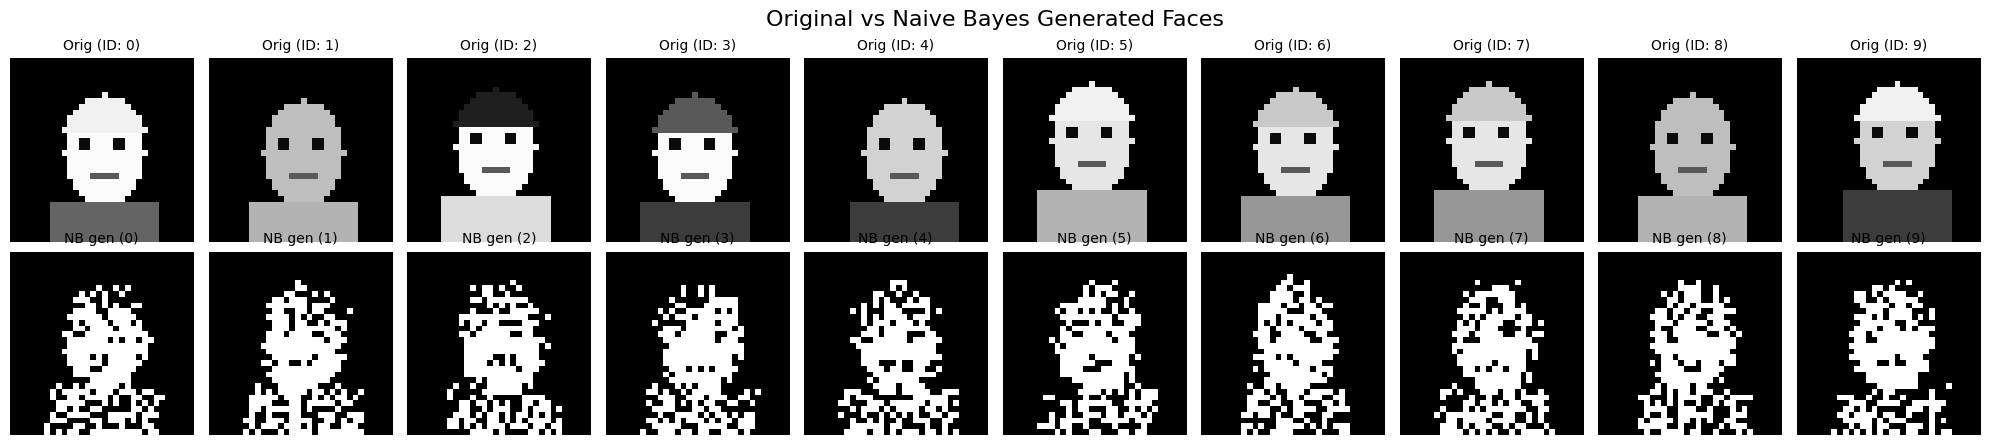

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import BernoulliNB

# 1. 데이터 준비
df = pd.read_csv('/content/planet_pixel_faces.csv')
pixel_cols = [c for c in df.columns if c.startswith('px_')]
X = df[pixel_cols].values                 # (N, 1024), 0~255
X_bin = (X > 127).astype(int)             # 이진화

rng = np.random.default_rng(0)
N_SHOW = 10

# 2. Naive Bayes 학습: 클래스 1개, 전체 데이터에서 픽셀별 P(px=1) 학습
model = BernoulliNB(alpha=1e-3)
model.fit(X_bin, np.zeros(len(X_bin), dtype=int))
p_pixel = np.exp(model.feature_log_prob_[0])

# 3. 새 이미지 생성: 픽셀을 독립적으로 샘플링
generated = (rng.random((N_SHOW, X.shape[1])) < p_pixel).astype(int)

# 4. 시각화: 원본 vs 생성
fig, axes = plt.subplots(2, N_SHOW, figsize=(2*N_SHOW, 4.5))
for i in range(N_SHOW):
    axes[0, i].imshow(X[i].reshape(32, 32), cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f"Orig (ID: {i})", fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(generated[i].reshape(32, 32), cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f"NB gen ({i})", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("Original vs Naive Bayes Generated Faces", fontsize=16)
plt.tight_layout()
plt.show()

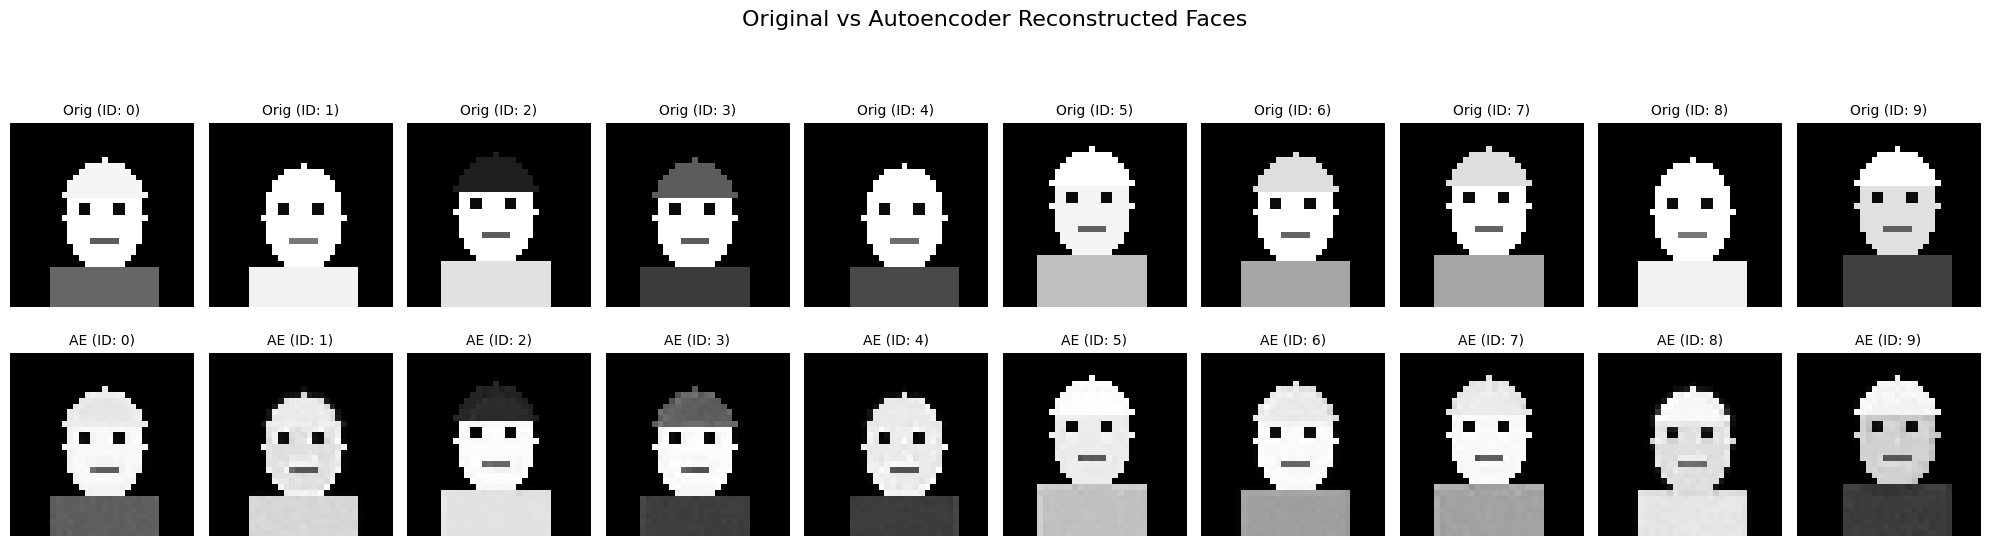

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 준비 및 전처리 (0 ~ 1 정규화)
df = pd.read_csv('/content/planet_pixel_faces.csv')
pixel_cols = [col for col in df.columns if col.startswith('px_')]

X = df[pixel_cols].values.astype(np.float32) / 255.0  # 0~1 range
y = df['face_id'].values

# PyTorch 텐서 및 데이터로더 생성
X_tensor = torch.tensor(X)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# 2. 간단한 MLP Autoencoder 모델 정의
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # 인코더: 1024차원 -> 64차원 압축
        self.encoder = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )
        # 디코더: 64차원 -> 1024차원 복원
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.Sigmoid()  # 출력을 0~1 범위로 제한
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# 3. 모델 학습 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# 50 에포크 동안 빠르게 학습
model.train()
for epoch in range(50):
    for batch in dataloader:
        inputs = batch[0].to(device)
        outputs = model(inputs)
        loss = criterion(outputs, inputs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# 4. 원본과 재생 이미지 비교 시각화
model.eval()
with torch.no_grad():
    # 비교할 10개 샘플 추출 및 예측
    sample_inputs = X_tensor[:10].to(device)
    reconstructed = model(sample_inputs).cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(20, 5.5))
for i in range(10):
    # 원본 이미지
    orig_img = X[i].reshape(32, 32)
    # 오토인코더 복원 이미지
    recon_img = reconstructed[i].reshape(32, 32)

    # 첫 번째 행: 원본
    axes[0, i].imshow(orig_img, cmap='gray')
    axes[0, i].set_title(f"Orig (ID: {y[i]})", fontsize=10)
    axes[0, i].axis('off')

    # 두 번째 행: Autoencoder 복원 결과
    axes[1, i].imshow(recon_img, cmap='gray')
    axes[1, i].set_title(f"AE (ID: {y[i]})", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("Original vs Autoencoder Reconstructed Faces", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


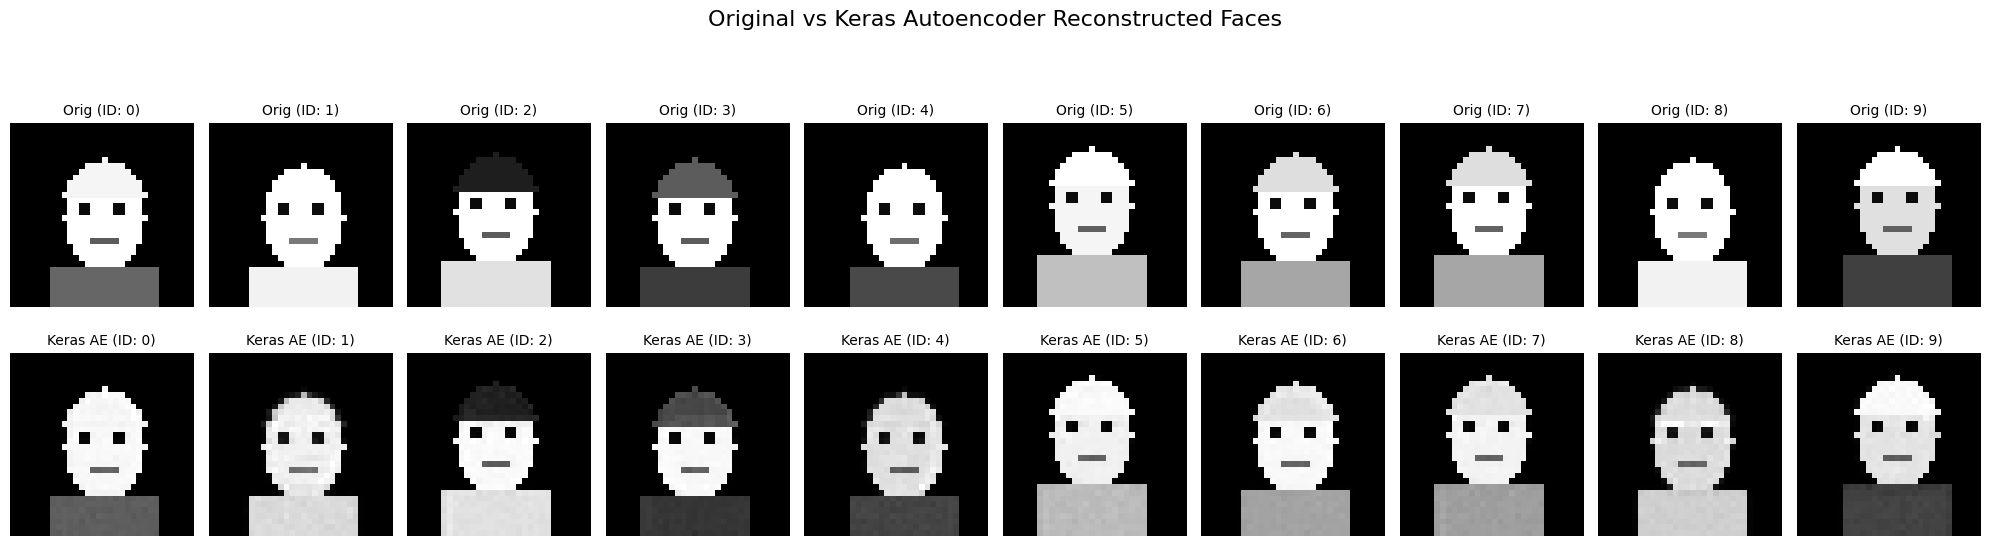

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# 1. 데이터 준비 및 전처리 (0 ~ 1 정규화)
df = pd.read_csv('/content/planet_pixel_faces.csv')
pixel_cols = [col for col in df.columns if col.startswith('px_')]

X = df[pixel_cols].values.astype('float32') / 255.0
y = df['face_id'].values

# 2. Keras를 이용한 Autoencoder 모델 설계
# 입력 레이어 (1024차원)
input_img = keras.Input(shape=(1024,))

# Encoder: 1024 -> 256 -> 64
encoded = layers.Dense(256, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)

# Decoder: 64 -> 256 -> 1024
decoded = layers.Dense(256, activation='relu')(encoded)
decoded = layers.Dense(1024, activation='sigmoid')(decoded) # 정규화된 출력을 위해 sigmoid 사용

# 전체 Autoencoder 모델 정의
autoencoder = keras.Model(input_img, decoded)

# 모델 컴파일
autoencoder.compile(optimizer='adam', loss='mse')

# 3. 모델 학습 (50 Epochs)
history = autoencoder.fit(
    X, X,
    epochs=50,
    batch_size=32,
    shuffle=True,
    verbose=0 # 학습 로그 생략
)

# 4. 원본과 Keras Autoencoder 재생 이미지 비교 시각화
reconstructed = autoencoder.predict(X[:10])

fig, axes = plt.subplots(2, 10, figsize=(20, 5.5))
for i in range(10):
    # 원본 이미지
    orig_img = X[i].reshape(32, 32)
    # Keras AE 복원 이미지
    recon_img = reconstructed[i].reshape(32, 32)

    # 첫 번째 행: 원본
    axes[0, i].imshow(orig_img, cmap='gray')
    axes[0, i].set_title(f"Orig (ID: {y[i]})", fontsize=10)
    axes[0, i].axis('off')

    # 두 번째 행: Keras Autoencoder 복원 결과
    axes[1, i].imshow(recon_img, cmap='gray')
    axes[1, i].set_title(f"Keras AE (ID: {y[i]})", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("Original vs Keras Autoencoder Reconstructed Faces", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### 5. Variational Autoencoder (VAE) 구현 및 학습

VAE는 단순 차원 축소가 아닌, 입력 데이터의 확률 분포를 학습합니다.
- **Encoder**: 이미지($32 \times 32 = 1024$)를 입력받아 잠재 공간의 평균($\mu$)과 로그 분산($\log \sigma^2$)을 출력합니다.
- **Reparameterization Trick**: $\mu + \epsilon \cdot \sigma$ (단, $\epsilon \sim N(0, I)$) 기법으로 미분 가능한 샘플링을 진행합니다.
- **Decoder**: 샘플링된 잠재 벡터(Latent Vector)를 다시 원래 이미지 크기($1024$)로 복원합니다.
- **Loss Function**: 복원 오차(Reconstruction Loss, MSE)와 잠재 공간 분포를 정규분포에 가깝게 만들어주는 KL 발산(Kullback-Leibler Divergence)의 합을 사용합니다.

Epoch [20/80], Loss: 16.0165
Epoch [40/80], Loss: 12.2158
Epoch [60/80], Loss: 11.3709
Epoch [80/80], Loss: 10.8264


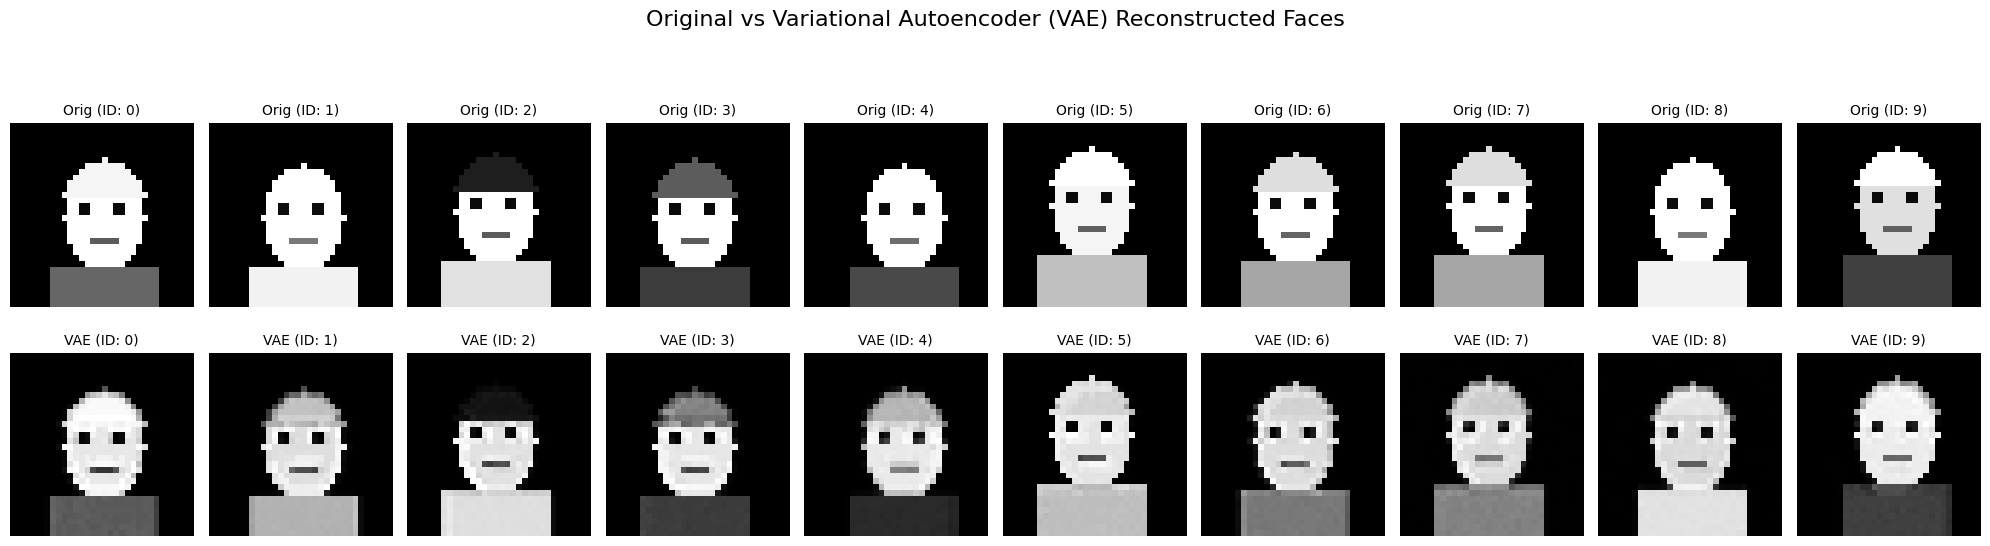

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 준비 및 전처리 (0 ~ 1 정규화)
df = pd.read_csv('/content/planet_pixel_faces.csv')
pixel_cols = [col for col in df.columns if col.startswith('px_')]

X = df[pixel_cols].values.astype(np.float32) / 255.0
y = df['face_id'].values

X_tensor = torch.tensor(X)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# 2. VAE 모델 정의
class VAE(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=256, latent_dim=32):
        super(VAE, self).__init__()

        # 인코더 구조
        self.encoder_fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)      # 평균
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)  # 로그 분산

        # 디코더 구조
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # 출력을 0~1 범위로 제한
        )

    def encode(self, x):
        h = self.encoder_fc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 3. 손실 함수 정의 (Reconstruction Loss + KL Divergence)
def vae_loss_fn(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE)
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')

    # KL Divergence
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kld_loss

# 4. 모델 학습 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vae_model = VAE().to(device)
optimizer = optim.Adam(vae_model.parameters(), lr=0.001)

# 80 에포크 동안 학습
vae_model.train()
for epoch in range(80):
    total_loss = 0
    for batch in dataloader:
        inputs = batch[0].to(device)
        outputs, mu, logvar = vae_model(inputs)
        loss = vae_loss_fn(outputs, inputs, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/80], Loss: {total_loss / len(dataloader.dataset):.4f}")

# 5. 원본과 VAE 재생 이미지 비교 시각화
vae_model.eval()
with torch.no_grad():
    sample_inputs = X_tensor[:10].to(device)
    reconstructed, _, _ = vae_model(sample_inputs)
    reconstructed = reconstructed.cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(20, 5.5))
for i in range(10):
    # 원본 이미지
    orig_img = X[i].reshape(32, 32)
    # VAE 복원 이미지
    recon_img = reconstructed[i].reshape(32, 32)

    # 첫 번째 행: 원본
    axes[0, i].imshow(orig_img, cmap='gray')
    axes[0, i].set_title(f"Orig (ID: {y[i]})", fontsize=10)
    axes[0, i].axis('off')

    # 두 번째 행: VAE 복원 결과
    axes[1, i].imshow(recon_img, cmap='gray')
    axes[1, i].set_title(f"VAE (ID: {y[i]})", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("Original vs Variational Autoencoder (VAE) Reconstructed Faces", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### 6. Keras를 이용한 Variational Autoencoder (VAE) 구현 및 학습

Keras의 Functional API와 subclassing 기법을 활용하여 VAE를 정의합니다.
- `Sampling` 레이어를 커스텀으로 구현하여 재매개변수화 기법(Reparameterization Trick)을 적용합니다.
- `train_step`을 커스텀 정의한 `VAE` 클래스를 만들어 학습 시 Reconstruction Loss와 KL Divergence를 통합하여 계산하도록 구성합니다.

Keras VAE 학습 시작...
Epoch 1/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - kl_loss: 10.9497 - loss: 92.3797 - reconstruction_loss: 81.4301 
Epoch 2/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - kl_loss: 5.0254 - loss: 40.8787 - reconstruction_loss: 35.8532
Epoch 3/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - kl_loss: 6.7764 - loss: 32.9549 - reconstruction_loss: 26.1785
Epoch 4/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - kl_loss: 6.8712 - loss: 28.0594 - reconstruction_loss: 21.1881
Epoch 5/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - kl_loss: 7.2069 - loss: 25.6734 - reconstruction_loss: 18.4664
Epoch 6/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - kl_loss: 6.9977 - loss: 24.1807 - reconstruction_loss: 17.1830
Epoch 7/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - kl_loss: 7.1679 - loss: 22.8195 - reconstruction_loss: 15.6517
Epoch 8/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - kl_loss: 7.1533 - loss: 21.6447 - reconstruction_loss: 14.4915
Epoch 9/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 

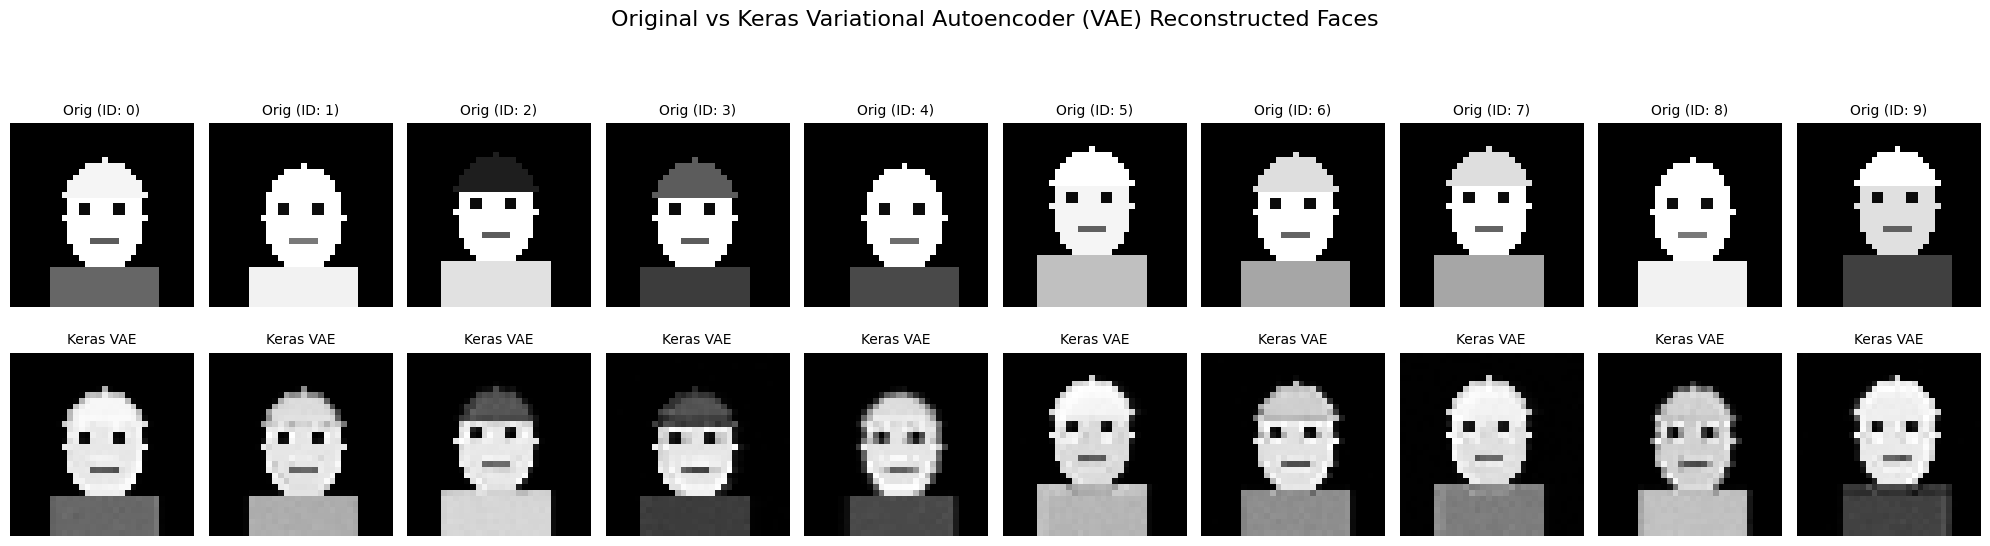

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. 데이터 준비 및 전처리 (0 ~ 1 정규화)
df = pd.read_csv('/content/planet_pixel_faces.csv')
pixel_cols = [col for col in df.columns if col.startswith('px_')]

X = df[pixel_cols].values.astype('float32') / 255.0
y = df['face_id'].values

# 2. VAE 구조 정의를 위한 Sampling Layer
class Sampling(layers.Layer):
    """평균(z_mean)과 로그 분산(z_log_var)을 사용해 잠재 벡터 z를 샘플링합니다."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# 3. 인코더(Encoder) 구축
latent_dim = 32
encoder_inputs = keras.Input(shape=(1024,))
x = layers.Dense(256, activation="relu")(encoder_inputs)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# 4. 디코더(Decoder) 구축
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(256, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(1024, activation="sigmoid")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

# 5. VAE 통합 모델 설계 (훈련 로직 재정의)
class KerasVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            # Reconstruction Loss: 직접 오차 제곱합 계산
            reconstruction_loss = tf.reduce_sum(tf.square(data - reconstruction), axis=-1)
            # KL Divergence Loss
            kl_loss = -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1
            )
            total_loss = tf.reduce_mean(reconstruction_loss + kl_loss)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(tf.reduce_mean(reconstruction_loss))
        self.kl_loss_tracker.update_state(tf.reduce_mean(kl_loss))
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# 6. 모델 학습 실행
keras_vae = KerasVAE(encoder, decoder)
keras_vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))

print("Keras VAE 학습 시작...")
keras_vae.fit(X, epochs=80, batch_size=32, verbose=1)
print("학습 완료!")

# 7. 시각화 비교 (10개 샘플)
_, _, z_sampled = keras_vae.encoder.predict(X[:10])
reconstructed = keras_vae.decoder.predict(z_sampled)

fig, axes = plt.subplots(2, 10, figsize=(20, 5.5))
for i in range(10):
    # 원본 이미지
    orig_img = X[i].reshape(32, 32)
    # Keras VAE 복원 이미지
    recon_img = reconstructed[i].reshape(32, 32)

    # 첫 번째 행: 원본
    axes[0, i].imshow(orig_img, cmap='gray')
    axes[0, i].set_title(f"Orig (ID: {y[i]})", fontsize=10)
    axes[0, i].axis('off')

    # 두 번째 행: Keras VAE 복원 결과
    axes[1, i].imshow(recon_img, cmap='gray')
    axes[1, i].set_title(f"Keras VAE", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("Original vs Keras Variational Autoencoder (VAE) Reconstructed Faces", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### 7. PCA (주성분 분석)를 이용한 차원 축소 및 복원

- **PCA (Principal Component Analysis)**: 데이터의 분산을 최대한 보존하는 축(주성분)을 찾아 투영하는 선형 차원 축소 기법입니다.
- 여기서는 이미지($1024$차원)를 $32$차원(앞선 VAE의 `latent_dim`과 동일)으로 축소한 뒤 복원하여 비선형 오토인코더 모델들과의 복원 성능을 시각적으로 비교해 봅니다.

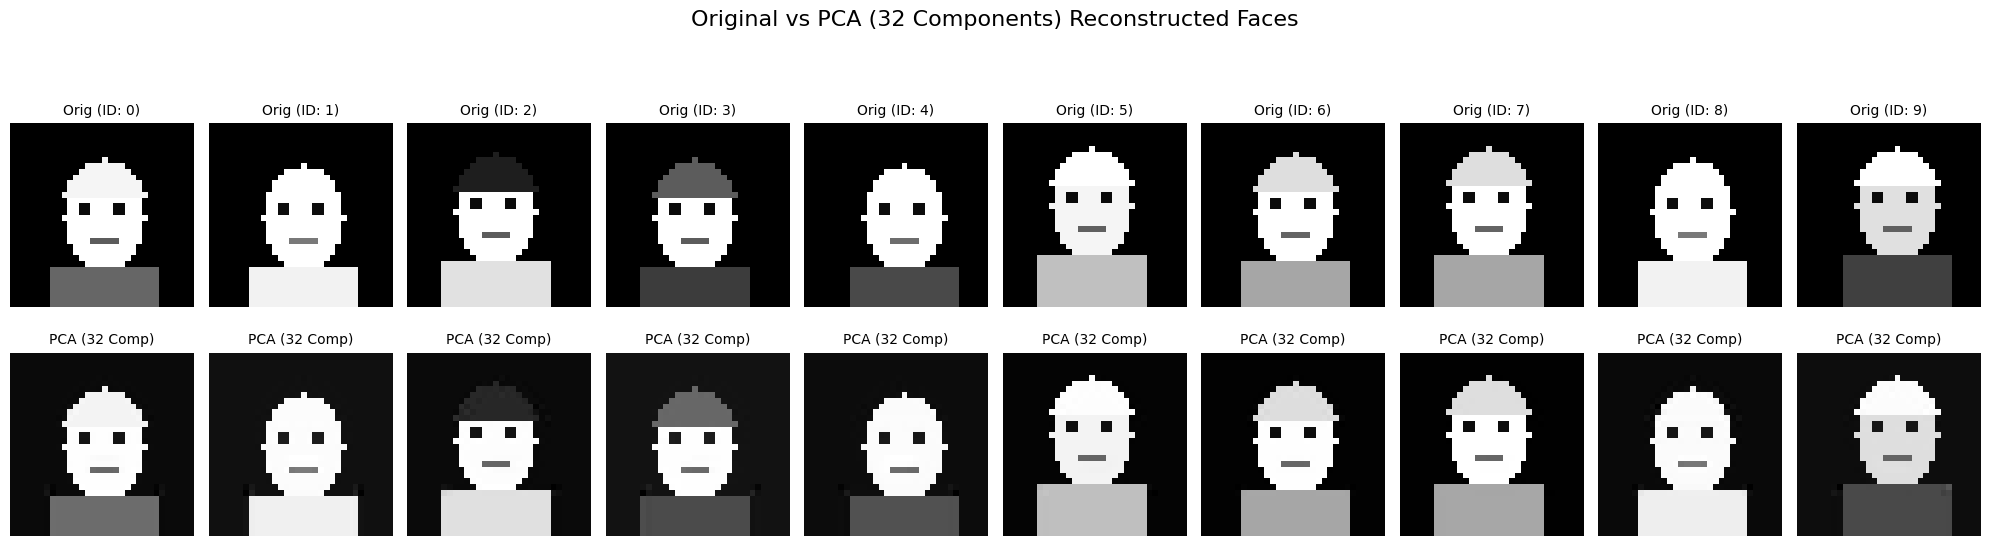

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. 데이터 준비
df = pd.read_csv('/content/planet_pixel_faces.csv')
pixel_cols = [col for col in df.columns if col.startswith('px_')]

X = df[pixel_cols].values.astype('float32') / 255.0
y = df['face_id'].values

# 2. PCA 모델 학습 및 차원 축소 (n_components=32)
pca = PCA(n_components=32, random_state=42)
X_pca = pca.fit_transform(X)

# 3. 압축된 차원으로부터 원래 차원으로 복원(재구성)
X_reconstructed = pca.inverse_transform(X_pca)

# 4. 시각화 비교 (10개 샘플)
fig, axes = plt.subplots(2, 10, figsize=(20, 5.5))
for i in range(10):
    # 원본 이미지
    orig_img = X[i].reshape(32, 32)
    # PCA 복원 이미지
    recon_img = X_reconstructed[i].reshape(32, 32)

    # 첫 번째 행: 원본
    axes[0, i].imshow(orig_img, cmap='gray')
    axes[0, i].set_title(f"Orig (ID: {y[i]})", fontsize=10)
    axes[0, i].axis('off')

    # 두 번째 행: PCA 복원 결과
    axes[1, i].imshow(recon_img, cmap='gray')
    axes[1, i].set_title(f"PCA (32 Comp)", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("Original vs PCA (32 Components) Reconstructed Faces", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### 8. Manifold Learning (Isomap)을 이용한 차원 축소 및 기하학적 분포 시각화

- **Manifold Learning**: 고차원 데이터가 사실은 저차원 비선형 다양체(Manifold) 상에 존재한다는 가정 하에 데이터의 고유한 구조를 보존하며 차원을 축소하는 기법입니다.
- **Isomap**: 데이터 포인트 간의 유클리드 거리가 아닌, 인접 이웃 그래프를 통한 최단 경로 거리(Geodesic Distance)를 보존하며 다차원 척도법(MDS)을 적용하는 대표적인 알고리즘입니다.
- 아래 코드에서는 $1024$차원의 데이터를 $2$차원으로 축소하고, 저차원 평면 위에 픽셀 캐릭터들을 플롯하여 매니폴드 공간의 흐름을 시각화합니다.

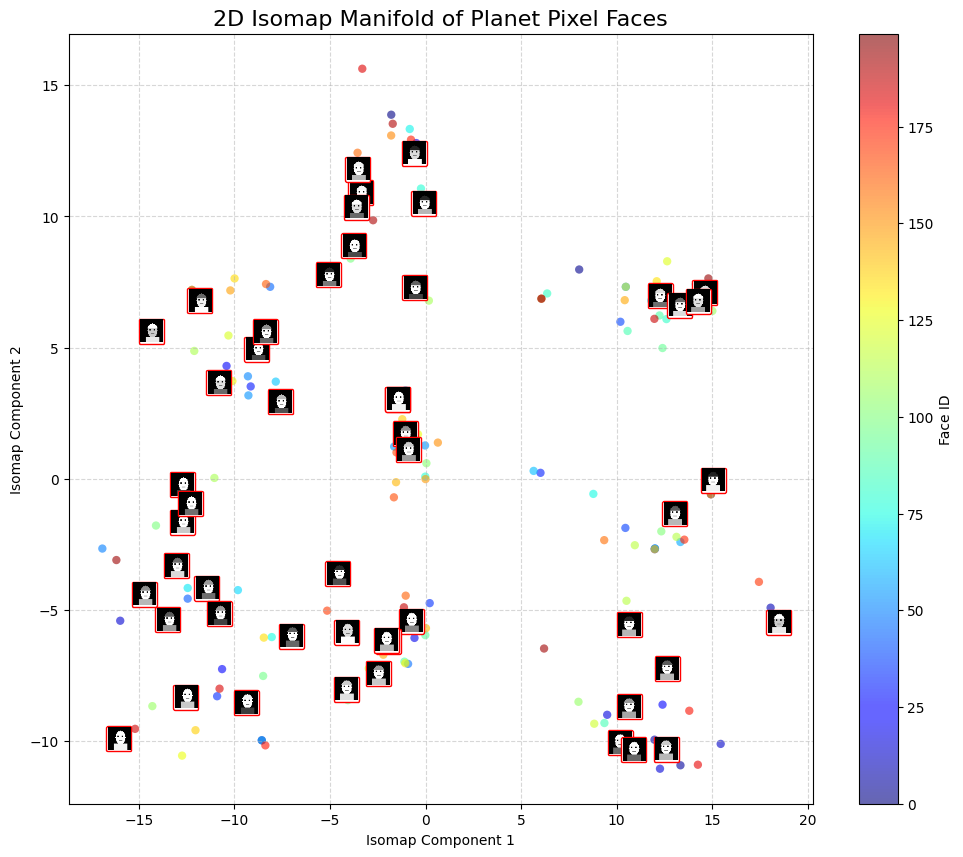

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# 1. 데이터 준비
df = pd.read_csv('/content/planet_pixel_faces.csv')
pixel_cols = [col for col in df.columns if col.startswith('px_')]

X = df[pixel_cols].values.astype('float32') / 255.0
y = df['face_id'].values

# 2. Isomap을 활용한 2차원 다양체 학습 (연산 속도를 위해 200개 샘플 사용)
n_samples_to_plot = 200
X_sub = X[:n_samples_to_plot]
y_sub = y[:n_samples_to_plot]

isomap = Isomap(n_neighbors=10, n_components=2)
X_isomap = isomap.fit_transform(X_sub)

# 3. 2차원 매니폴드 공간 시각화
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_isomap[:, 0], X_isomap[:, 1], c=y_sub, cmap='jet', alpha=0.6, edgecolors='none')

# 2차원 평면 위에 실제 이미지 오버레이 매핑
for i in range(0, n_samples_to_plot, 4):  # 겹치지 않도록 일부 샘플만 시각화
    img = X_sub[i].reshape(32, 32)
    imagebox = OffsetImage(img, cmap='gray', zoom=0.5)
    ab = AnnotationBbox(imagebox, (X_isomap[i, 0], X_isomap[i, 1]),
                        frameon=True, bboxprops=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.1'))
    ax.add_artist(ab)

plt.colorbar(scatter, label='Face ID')
plt.title("2D Isomap Manifold of Planet Pixel Faces", fontsize=16)
plt.xlabel("Isomap Component 1")
plt.ylabel("Isomap Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()